In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime as dt
from datetime import time
from datetime import timedelta

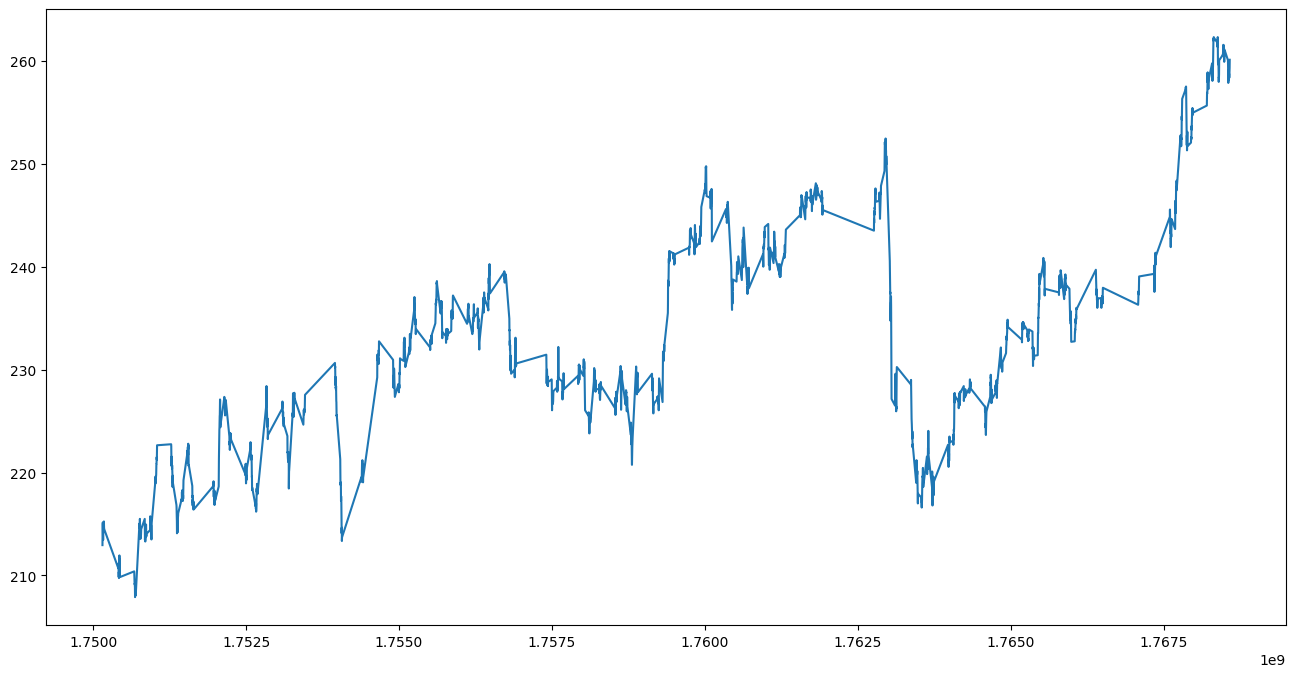

In [69]:
from datetime import datetime, timezone
df = pd.read_csv('SIE_intraday.csv')
df['Datum'] = pd.to_datetime(df['Datum'])
df['Uhrzeit'] = pd.to_timedelta(df['Uhrzeit'])
df['Timestamp'] = df['Datum'] + df['Uhrzeit']

# ISO-Strings in datetime umwandeln
df["datetime"] = pd.to_datetime(df["Timestamp"])

# In Unix-Zeitstempel (Sekunden seit 1970) konvertieren
df["unix_ts"] = df["datetime"].astype("int64") / 1e9

# print(df)
# df['unix_ts'] = df['unix_ts'] - pd.Timestamp(0)
Zeit = df['unix_ts'].to_numpy()
Kurs = df['Kurs_EUR'].to_numpy()

plt.figure(figsize=(16, 8))
plt.plot(Zeit, Kurs)

In [70]:
def penis(Zeit, Kurs, Intervall1, Intervall2, starttime = 0):
    Differenz = []
    Intervalls = []
    offset = int(starttime//1800)
    Zeit_0 = Zeit[0+offset]
    while Zeit_0 <= np.max(Zeit):
        # print('hi')
        for j in range(len(Zeit)):
            if Zeit[j] == Zeit_0 + Intervall2 and Kurs[np.where(Zeit==Zeit_0)] is not None:
                Differenz.append(Kurs[j]/Kurs[np.where(Zeit == Zeit_0)])
                Intervalls.append([Zeit_0, Zeit[j]])
        Zeit_0 += Intervall1
    Intervalls = np.array(Intervalls)
    Differenz = np.array(Differenz)
    return Differenz, Intervalls

In [73]:
Results = np.zeros((4,10))
Errors = np.zeros((4,10))
for i in range(1, 5):
    for j in range(0, 10):
        Intervall1 = 1 * 24 * 3600
        Intervall2 = i * 3600
        starttime =  j * 1800
        Differenz, Intervalls = penis(Zeit=Zeit, Kurs=Kurs, Intervall1 = Intervall1, Intervall2=Intervall2, starttime= starttime)
        Prod = np.mean(Differenz)
        err = np.std(Differenz)
        Results[i-1][j] = Prod
        Errors[i-1][j] = err
# print(Differenz)
# print(Intervalls)
print(Results)
print(Errors)
print(np.max(Results), np.argmax(Results))

[[1.00033751 0.99968299 0.99984174 1.00002562 0.99984657 0.99990631
  1.00003608 1.00049853 1.00025797 0.99997358]
 [1.0001816  0.99970757 0.99968902 0.99993379 0.99988194 1.00040481
  1.00026661 1.00044331 1.00046029 0.99985966]
 [1.00002941 0.99961605 0.99972489 1.00043122 1.00012082 1.00033026
  1.00046919 1.00032836 1.00031877 0.99966987]
 [1.00006664 1.00011391 0.9999383  1.00036122 1.00032338 1.00021672
  1.00032729 1.00013604 1.00026519 1.00291059]]
[[0.0048668  0.00425596 0.00344054 0.00358312 0.00356935 0.00316616
  0.00316158 0.00320884 0.00306744 0.00315157]
 [0.00635486 0.00537549 0.00509223 0.00515138 0.0046165  0.00451336
  0.00450731 0.00457562 0.00479698 0.00533763]
 [0.0074556  0.00657043 0.00595909 0.00589358 0.0058595  0.00550532
  0.00586843 0.00612958 0.00618941 0.00689295]
 [0.00824586 0.00725266 0.00683519 0.00684685 0.00696678 0.00705089
  0.00699994 0.00719581 0.00788451 0.        ]]
1.0029105902213813 39


In [67]:
Intervall1 = 1 * 24 * 3600
Intervall2 = 2 * 3600
starttime =  7 * 1800
Differenz, Intervalls = penis(Zeit=Zeit, Kurs=Kurs, Intervall1 = Intervall1, Intervall2=Intervall2, starttime= starttime)
Prod = np.prod(Differenz)
print(Differenz)
print(Intervalls)
print(Prod)

[[0.98858447]
 [1.00232423]
 [1.        ]
 [1.00469071]
 [0.99331978]
 [1.00220568]
 [0.98603742]
 [1.00846501]
 [1.00170648]
 [1.0041225 ]
 [0.99589202]
 [0.99856938]
 [1.00300958]
 [1.00217273]
 [1.01060359]
 [1.01807061]
 [1.00570807]
 [0.99085038]
 [1.00110284]
 [0.99729437]
 [1.0077886 ]
 [0.9813058 ]
 [1.001983  ]
 [1.00432028]
 [1.00344828]
 [0.99706228]
 [0.99633183]
 [0.99080664]
 [1.00579151]
 [1.00354381]
 [0.99468085]
 [1.003367  ]
 [1.00688145]
 [1.00239736]
 [0.98168614]
 [1.00129116]
 [0.99875506]
 [1.00494132]
 [1.00273973]
 [0.99571865]
 [0.99725526]
 [1.00091687]
 [1.00558824]
 [1.00954033]
 [0.99026903]
 [0.99378355]
 [1.01098266]
 [1.01386194]
 [1.00215983]
 [1.00132767]
 [1.00336352]
 [0.99590897]
 [0.99431231]
 [0.99632739]
 [1.00705513]
 [0.99484137]
 [0.99608866]
 [1.00025634]
 [1.00255102]
 [1.00406091]
 [0.99424568]
 [0.99974741]
 [1.00207147]
 [1.00508388]
 [0.99949799]
 [0.98626653]
 [1.00026624]
 [1.00337487]
 [0.99659953]
 [1.00616126]
 [0.99706588]
 [1.01

In [77]:
I = 5
J = 10
K = 10
Matrix = np.zeros((I,J,K))
for i in range(1,I):
    Intervall1 = i * 24 * 3600
    for j in range(1,J):
        Intervall2 = j * 1800
        for k in range(K):
            starttime = k * 1800
            Differenz, Intervalls = penis(Zeit=Zeit, Kurs=Kurs, Intervall1 = Intervall1, Intervall2=Intervall2, starttime= starttime)
            Prod = np.prod(Differenz)
            Matrix[i,j,k] = Prod

In [80]:
print(np.max(Matrix), np.argmax(Matrix))
print(Kurs[-1]/Kurs[0])

1.0306361415296494 120
1.0307601115313207


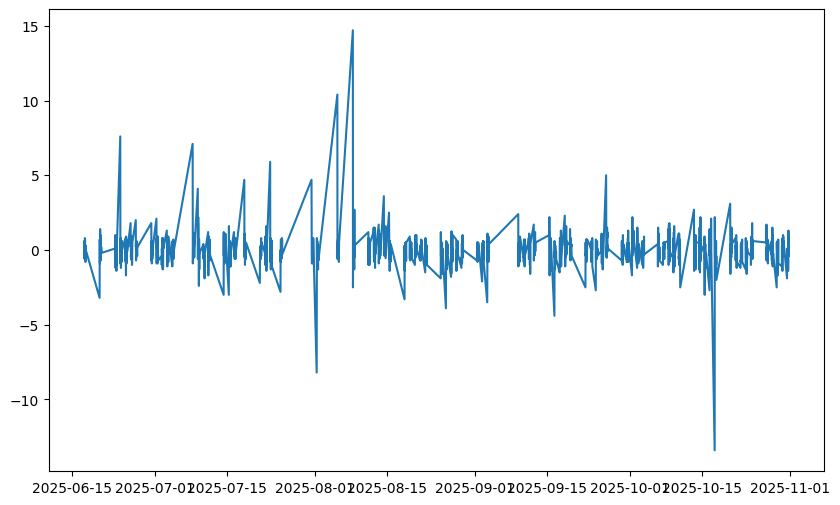

In [5]:
diff_array = df['Kurs_EUR'].diff()

plt.figure(figsize=(10, 6))
plt.plot(Zeit, diff_array)

In [6]:
import numpy as np
import datetime

# --- Beispieldaten (ersetze diese durch deine echten Daten) ---
# Erstellen wir eine plausible Zeitreihe für die Demonstration
# zeit_start = datetime.datetime(2024, 1, 1)
# anzahl_tage = 200
# Zeit-Array mit täglichen Daten
zeit = Zeit

# Kurs-Array: Eine Mischung aus stabilem Wachstum und volatilen Phasen
kurs = Kurs

# diff_array: Die Differenz zwischen aufeinanderfolgenden Kurswerten
diff_array = np.diff(kurs)
# Wir brauchen für die Analyse den Kurs und die Differenzen ab dem zweiten Tag
kurs_analyse = kurs[1:]
zeit_analyse = zeit[1:]

# --- Analyse-Parameter (diese kannst du anpassen) ---

# Größe des Zeitfensters in Tagen
fenster_groesse = 30
# Mindestwachstum in Prozent, das in diesem Fenster erreicht werden muss
wachstums_schwelle = 2
# Maximale Anzahl an Tagen, an denen der Kurs fallen darf
max_rueckgaenge = 10

# --- Analyse mit dem gleitenden Fenster ---

gefundene_intervalle = []

# Wir durchlaufen die Daten mit dem Fenster
# Der Loop stoppt, sodass das Fenster nicht über das Ende der Daten hinausragt
for i in range(len(diff_array) - fenster_groesse + 1):
    # Aktuelles Fenster aus den Daten extrahieren
    start_index = i
    end_index = i + fenster_groesse

    fenster_diff = diff_array[start_index:end_index]
    kurs_start = kurs_analyse[start_index]
    kurs_ende = kurs_analyse[end_index - 1]

    # 1. Kriterium: Wachstum berechnen
    gesamtwachstum = ((kurs_ende - kurs_start) / kurs_start) * 100

    # 2. Kriterium: Anzahl der Rückgänge zählen
    anzahl_rueckgaenge = np.sum(fenster_diff < 0)

    # Prüfen, ob beide Kriterien erfüllt sind
    if gesamtwachstum >= wachstums_schwelle and anzahl_rueckgaenge <= max_rueckgaenge:
        # Wenn ja, speichere das Start- und Enddatum des Intervalls
        intervall_start = zeit_analyse[start_index]
        intervall_ende = zeit_analyse[end_index - 1]
        gefundene_intervalle.append({
            "start": intervall_start,
            "ende": intervall_ende,
            "wachstum": gesamtwachstum,
            "rueckgaenge": anzahl_rueckgaenge
        })

# --- Ergebnisse ausgeben ---
if gefundene_intervalle:
    print(f"Es wurden {len(gefundene_intervalle)} passende Intervalle gefunden:\n")
    for intervall in gefundene_intervalle:
        print(f"Intervall: {intervall['start'].strftime('%Y-%m-%d')} bis {intervall['ende'].strftime('%Y-%m-%d')}")
        print(f"  -> Wachstum: {intervall['wachstum']:.2f}%")
        print(f"  -> Tage mit Kursrückgang: {intervall['rueckgaenge']} von {fenster_groesse} Tagen\n")
else:
    print("Keine Intervalle gefunden, die den Kriterien entsprechen.")
    print("Tipp: Versuche, die `wachstums_schwelle` zu senken oder `max_rueckgaenge` zu erhöhen.")

Es wurden 47 passende Intervalle gefunden:



AttributeError: 'numpy.datetime64' object has no attribute 'strftime'